In [1]:
import boto3

# Подключение к MinIO
s3 = boto3.client(
    "s3",
    endpoint_url="http://localhost:9000",
    aws_access_key_id="admin",
    aws_secret_access_key="Admin12345"
)

# Создаём бакет (если уже есть — будет ошибка, это нормально)
bucket_name = "university-data"
try:
    s3.create_bucket(Bucket=bucket_name)
    print(f"Бакет '{bucket_name}' создан.")
except s3.exceptions.BucketAlreadyOwnedByYou:
    print(f"Бакет '{bucket_name}' уже существует.")
except Exception as e:
    print(f"Ошибка: {e}")

# Выводим список бакетов для проверки
response = s3.list_buckets()
print("\nСписок бакетов:")
for bucket in response["Buckets"]:
    print(" -", bucket["Name"])

Бакет 'university-data' создан.

Список бакетов:
 - okey
 - university-data


# Начинаем лабу 1

In [2]:
from pathlib import Path
import pandas as pd
import boto3
import matplotlib.pyplot as plt
import seaborn as sns

# Конфиг MinIO
MINIO_ENDPOINT = "http://localhost:9000"
MINIO_KEY = "admin"
MINIO_SECRET = "Admin12345"
BUCKET = "cardio-data"

# Пути
BASE_DIR = Path.cwd()
CSV_PATH = BASE_DIR / "data.csv"
PARQUET_PATH = BASE_DIR / "cardio.parquet"

# Boto3 клиент
s3 = boto3.client(
    "s3",
    endpoint_url=MINIO_ENDPOINT,
    aws_access_key_id=MINIO_KEY,
    aws_secret_access_key=MINIO_SECRET
)

print("Рабочая директория:", BASE_DIR)
print("CSV существует:", CSV_PATH.exists())
print("Бакеты:", [b["Name"] for b in s3.list_buckets()["Buckets"]])

Рабочая директория: c:\Users\Пользователь\Desktop\Новая папка
CSV существует: True
Бакеты: ['okey', 'university-data']


In [3]:
try:
    s3.create_bucket(Bucket=BUCKET)
    print(f"Бакет '{BUCKET}' создан.")
except s3.exceptions.BucketAlreadyOwnedByYou:
    print(f"Бакет '{BUCKET}' уже существует.")
except Exception as e:
    print(f"Ошибка: {e}")

print("Все бакеты:", [b["Name"] for b in s3.list_buckets()["Buckets"]])

Бакет 'cardio-data' создан.
Все бакеты: ['cardio-data', 'okey', 'university-data']


In [4]:
df = pd.read_csv(CSV_PATH)

print("Размер:", df.shape)
print("Колонки:", list(df.columns))
print("\nПервые 5 строк:")
display(df.head())

print("\nТипы:")
print(df.dtypes)

print("\nПропуски:")
print(df.isna().sum()[df.isna().sum() > 0] if df.isna().sum().sum() else "нет пропусков")

print("\nДубликаты:", df.duplicated().sum())

print("\nБаланс классов:")
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True).round(3))

Размер: (87554, 13)
Колонки: ['mean', 'std_dev', 'energy', 'peak_count', 'rms', 'skewness', 'kurtosis', 'zero_crossings', 'dominant_freq', 'entropy', 'max_amplitude', 'slope', 'label']

Первые 5 строк:


,mean,std_dev,energy,peak_count,rms,skewness,kurtosis,zero_crossings,dominant_freq,entropy,max_amplitude,slope,label
0,0.098419,0.176073,7.60865,1,0.201713,3.54620,13.6255,0,0.004344,4.22037,1.0,-0.001393,0
1,0.090010,0.159722,6.28563,3,0.183338,3.83501,16.2614,0,0.004285,4.31934,1.0,-0.000992,0
2,0.062104,0.138769,4.32229,2,0.152032,4.32459,22.1669,0,0.005715,3.93176,1.0,-0.001128,0
3,0.084084,0.160821,6.15856,2,0.181476,3.47749,13.6918,0,0.003292,4.07658,1.0,-0.001226,0
4,0.116567,0.186151,9.02094,2,0.219637,3.10973,10.2389,0,0.003089,4.38846,1.0,-0.001149,0



Типы:
mean              float64
std_dev           float64
energy            float64
peak_count          int64
rms               float64
skewness          float64
kurtosis          float64
zero_crossings      int64
dominant_freq     float64
entropy           float64
max_amplitude     float64
slope             float64
label               int64
dtype: object

Пропуски:
нет пропусков

Дубликаты: 0

Баланс классов:
label
0    72471
1    15083
Name: count, dtype: int64
label
0    0.828
1    0.172
Name: proportion, dtype: float64


In [5]:
# Сохраняем Parquet локально
df.to_parquet(PARQUET_PATH, index=False)
print(f"Parquet: {PARQUET_PATH.name}, {PARQUET_PATH.stat().st_size / 1024:.1f} КБ")

# Грузим оба файла в MinIO
s3.upload_file(str(CSV_PATH), BUCKET, "raw/cardio.csv")
s3.upload_file(str(PARQUET_PATH), BUCKET, "processed/cardio.parquet")
print("Загружено в MinIO.")

# Проверяем содержимое бакета
print("\nСодержимое бакета:")
for obj in s3.list_objects_v2(Bucket=BUCKET).get("Contents", []):
    print(f"  {obj['Key']:40s} {obj['Size']:>8} байт")

Parquet: cardio.parquet, 7000.2 КБ
Загружено в MinIO.

Содержимое бакета:
  processed/cardio.parquet                  7168166 байт
  raw/cardio.csv                            7982325 байт


In [6]:
storage_options = {
    "key": MINIO_KEY,
    "secret": MINIO_SECRET,
    "client_kwargs": {"endpoint_url": MINIO_ENDPOINT}
}

df_from_minio = pd.read_parquet(
    f"s3://{BUCKET}/processed/cardio.parquet",
    storage_options=storage_options
)

print("Прочитано из MinIO:", df_from_minio.shape)
display(df_from_minio.head())

# Проверим, что данные идентичны локальным
print("Данные совпадают с локальными:", df.equals(df_from_minio))

c:\Users\Пользователь\AppData\Local\Programs\Python\Python312\Lib\site-packages\fsspec\registry.py:298: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


Прочитано из MinIO: (87554, 13)


,mean,std_dev,energy,peak_count,rms,skewness,kurtosis,zero_crossings,dominant_freq,entropy,max_amplitude,slope,label
0,0.098419,0.176073,7.60865,1,0.201713,3.54620,13.6255,0,0.004344,4.22037,1.0,-0.001393,0
1,0.090010,0.159722,6.28563,3,0.183338,3.83501,16.2614,0,0.004285,4.31934,1.0,-0.000992,0
2,0.062104,0.138769,4.32229,2,0.152032,4.32459,22.1669,0,0.005715,3.93176,1.0,-0.001128,0
3,0.084084,0.160821,6.15856,2,0.181476,3.47749,13.6918,0,0.003292,4.07658,1.0,-0.001226,0
4,0.116567,0.186151,9.02094,2,0.219637,3.10973,10.2389,0,0.003089,4.38846,1.0,-0.001149,0


Данные совпадают с локальными: True


In [8]:
FEATURES = [c for c in df_from_minio.columns if c != "label"]

# Средние по классам
means = df_from_minio.groupby("label")[FEATURES].mean().T
means.columns = [f"label={c}" for c in means.columns]
print("Средние по классам:")
display(means.round(4))

# Разница средних — топ признаков
diff = (df_from_minio[df_from_minio["label"] == 1][FEATURES].mean()
        - df_from_minio[df_from_minio["label"] == 0][FEATURES].mean()).abs().sort_values(ascending=False)

print("\nТоп признаков по |разнице средних| между классами:")
display(diff.round(4))

Средние по классам:


,label=0,label=1
mean,0.1619,0.2338
std_dev,0.1861,0.2260
energy,13.7527,22.4960
peak_count,3.1845,3.5940
rms,0.2517,0.3296
skewness,2.3648,1.1842
kurtosis,9.7445,3.2178
zero_crossings,0.0000,0.0000
dominant_freq,0.0053,0.0038
entropy,4.4151,4.5609



Топ признаков по |разнице средних| между классами:


energy            8.7433
kurtosis          6.5267
skewness          1.1807
peak_count        0.4095
entropy           0.1458
rms               0.0779
mean              0.0719
std_dev           0.0398
dominant_freq     0.0015
max_amplitude     0.0013
slope             0.0007
zero_crossings    0.0000
dtype: float64

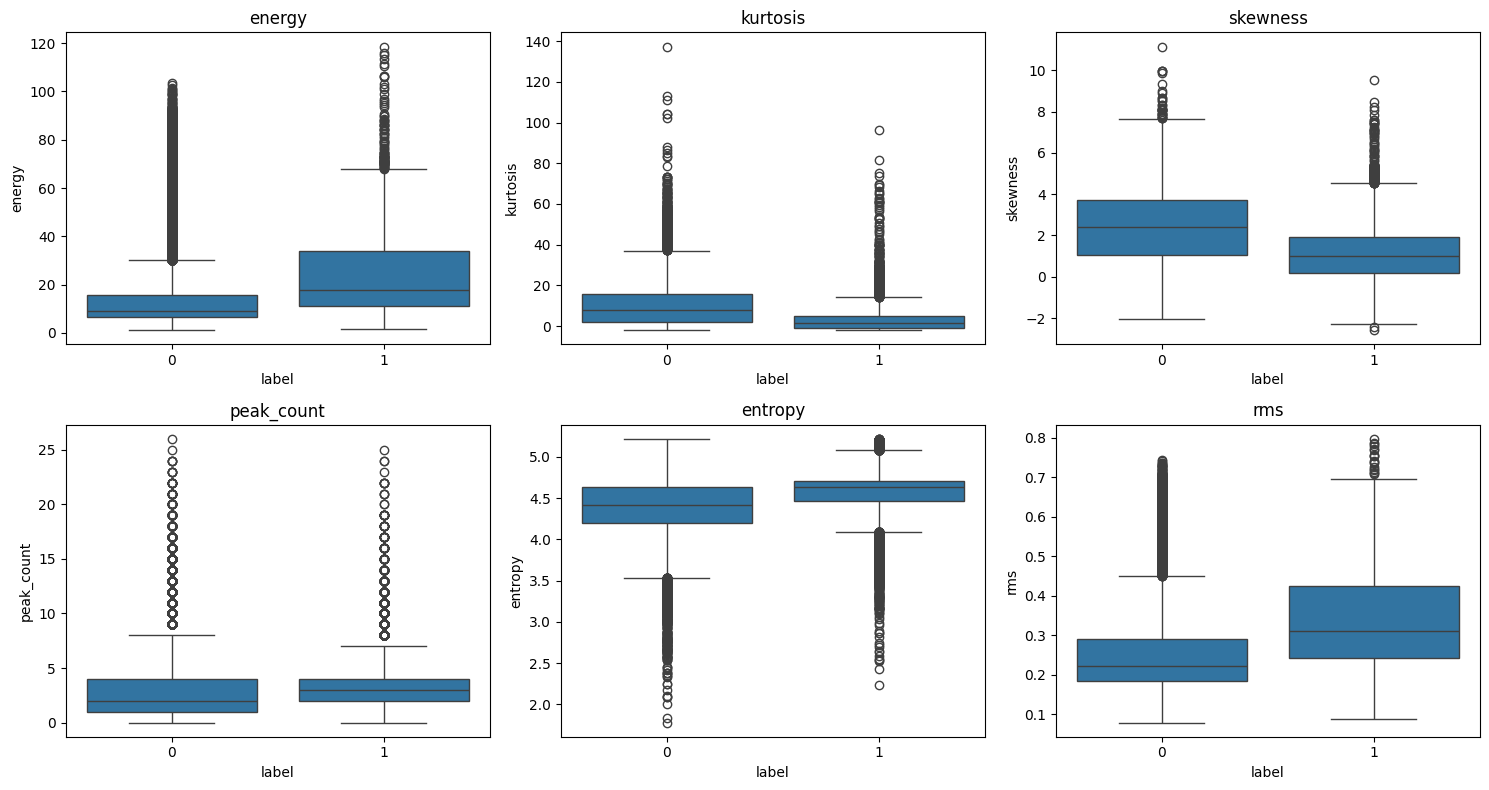

In [9]:
top_features = diff.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, top_features):
    sns.boxplot(data=df_from_minio, x="label", y=feat, ax=ax)
    ax.set_title(feat)
plt.tight_layout()
plt.show()

In [10]:
stats = df_from_minio.groupby("label")[FEATURES].agg(["mean", "std"]).reset_index()
stats.columns = ["_".join([str(c) for c in col if c]) for col in stats.columns]

stats.to_parquet("cardio_statistics.parquet", index=False)
s3.upload_file("cardio_statistics.parquet", BUCKET, "analytics/cardio_statistics.parquet")

print("Загружено: s3://cardio-data/analytics/cardio_statistics.parquet")
print("\nФинальное содержимое бакета:")
for obj in s3.list_objects_v2(Bucket=BUCKET).get("Contents", []):
    print(f"  {obj['Key']:45s} {obj['Size']:>8} байт")

Загружено: s3://cardio-data/analytics/cardio_statistics.parquet

Финальное содержимое бакета:
  analytics/cardio_statistics.parquet              15713 байт
  processed/cardio.parquet                       7168166 байт
  raw/cardio.csv                                 7982325 байт


In [11]:
df_analytics = pd.read_parquet(
    f"s3://{BUCKET}/analytics/cardio_statistics.parquet",
    storage_options=storage_options
)
print("analytics из MinIO:", df_analytics.shape)
print("Колонки:", list(df_analytics.columns)[:6], "...")
display(df_analytics.head())

analytics из MinIO: (2, 25)
Колонки: ['label', 'mean_mean', 'mean_std', 'std_dev_mean', 'std_dev_std', 'energy_mean'] ...


,label,mean_mean,mean_std,std_dev_mean,std_dev_std,energy_mean,energy_std,peak_count_mean,peak_count_std,rms_mean,...,zero_crossings_mean,zero_crossings_std,dominant_freq_mean,dominant_freq_std,entropy_mean,entropy_std,max_amplitude_mean,max_amplitude_std,slope_mean,slope_std
0,0,0.161896,0.102035,0.186145,0.047670,13.752735,13.539911,3.184501,2.856457,0.251696,...,0.0,0.0,0.005304,0.001968,4.415086,0.330847,0.999967,0.002267,-0.001932,0.001055
1,1,0.233798,0.101949,0.225959,0.064715,22.496002,14.450444,3.594046,2.610676,0.329579,...,0.0,0.0,0.003788,0.001674,4.560911,0.319921,0.998633,0.015816,-0.002628,0.001346
